In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

os.chdir('../cross-rag')

def parse_result_file(file_path):
    results_dict = {}  # Use a dictionary to keep only the last result per dataset
    with open(file_path, 'r') as f:
        lines = f.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if not line:
            i += 1
            continue
        if '_zeroshot_' in line:
            dataset = line.split('_zeroshot_')[0]
            if i + 1 < len(lines):
                metric_line = lines[i + 1].strip()
                mse_match = re.search(r'mse:([\d.]+)', metric_line)
                mae_match = re.search(r'mae:([\d.]+)', metric_line)
                if mse_match and mae_match:
                    # Update dictionary - later results will overwrite earlier ones
                    results_dict[dataset] = {
                        'dataset': dataset,
                        'mse': float(mse_match.group(1)),
                        'mae': float(mae_match.group(1))
                    }
                i += 2
            else:
                i += 1
        else:
            i += 1
    return pd.DataFrame(list(results_dict.values()))

In [2]:
PATH = f'results/forecast_evaluation'
settings = os.listdir(PATH)
settings = [x for x in settings if 'alpha' in x]
settings = sorted(settings)
os.chdir(PATH)

In [3]:
settings_base = [x for x in settings if 'dualhead' not in x]
settings_base = [x for x in settings_base if 'k5' in x]
settings_ours = [x for x in settings if 'dualhead' in x]
settings_ours = [x for x in settings_ours if 'k15' in x]
print(len(settings_base))
print(len(settings_ours))

6
18


In [4]:
ours_alpha5 = [x for x in settings_ours if 'alpha5.' in x]
ours_alpha10 = [x for x in settings_ours if 'alpha10.' in x]
ours_alpha20 = [x for x in settings_ours if 'alpha20.' in x]
ours_alpha25 = [x for x in settings_ours if 'alpha25.' in x]
ours_alpha50 = [x for x in settings_ours if 'alpha50.' in x]
ours_alpha75 = [x for x in settings_ours if 'alpha75.' in x]

In [5]:
base_alpha5 = [x for x in settings_base if 'alpha5.' in x]
base_alpha10 = [x for x in settings_base if 'alpha10.' in x]
base_alpha20 = [x for x in settings_base if 'alpha20.' in x]
base_alpha25 = [x for x in settings_base if 'alpha25.' in x]
base_alpha50 = [x for x in settings_base if 'alpha50.' in x]
base_alpha75 = [x for x in settings_base if 'alpha75.' in x]

In [6]:
results_base = []
exchange_base = []
etth1_base = []
etth2_base = []
ettm1_base = []
ettm2_base = []
weather_base = []
electricity_base = []

for base in [base_alpha5, base_alpha10,base_alpha20,
            base_alpha25,base_alpha50,base_alpha75]:
    x = base[0]
    df_base = parse_result_file(x)
    df_base.set_index('dataset',inplace=True)
    df_base.loc['avg'] = df_base.mean(axis=0)    
    results_base.extend(list(df_base['mse'].drop('avg').values))
    exchange_base.append(df_base['mse'].loc['exchange_rate'])
    etth1_base.append(df_base['mse'].loc['ETTh1'])
    etth2_base.append(df_base['mse'].loc['ETTh2'])
    ettm1_base.append(df_base['mse'].loc['ETTm1'])
    ettm2_base.append(df_base['mse'].loc['ETTm2'])
    weather_base.append(df_base['mse'].loc['weather'])
    electricity_base.append(df_base['mse'].loc['electricity'])
    
    display(df_base)

,mse,mae
dataset,,
exchange_rate,0.086800,0.198300
ETTh1,0.357000,0.364900
ETTh2,0.241100,0.296900
ETTm1,0.304000,0.320000
ETTm2,0.151800,0.229600
weather,0.158700,0.194400
electricity,0.113400,0.202700
avg,0.201829,0.258114


,mse,mae
dataset,,
exchange_rate,0.097800,0.211000
ETTh1,0.355800,0.364600
ETTh2,0.239600,0.296500
ETTm1,0.304000,0.320100
ETTm2,0.149500,0.227900
weather,0.156600,0.192000
electricity,0.114500,0.205500
avg,0.202543,0.259657


,mse,mae
dataset,,
exchange_rate,0.085300,0.199400
ETTh1,0.356400,0.363600
ETTh2,0.240700,0.296900
ETTm1,0.303400,0.319200
ETTm2,0.149000,0.227300
weather,0.154800,0.189800
electricity,0.114000,0.204100
avg,0.200514,0.257186


,mse,mae
dataset,,
exchange_rate,0.088500,0.203200
ETTh1,0.355300,0.363600
ETTh2,0.241600,0.296400
ETTm1,0.302100,0.318900
ETTm2,0.148900,0.226800
weather,0.156600,0.190900
electricity,0.114300,0.205400
avg,0.201043,0.257886


,mse,mae
dataset,,
exchange_rate,0.078400,0.192500
ETTh1,0.356000,0.363000
ETTh2,0.240800,0.296400
ETTm1,0.302600,0.318800
ETTm2,0.148600,0.226800
weather,0.156700,0.191500
electricity,0.114500,0.205300
avg,0.199657,0.256329


,mse,mae
dataset,,
exchange_rate,0.078600,0.193100
ETTh1,0.357500,0.363700
ETTh2,0.242500,0.296800
ETTm1,0.301700,0.318300
ETTm2,0.148500,0.226100
weather,0.154700,0.189300
electricity,0.113500,0.202900
avg,0.199571,0.255743


In [7]:
results_ours = []
exchange_ours = []
etth1_ours = []
etth2_ours = []
ettm1_ours = []
ettm2_ours = []
weather_ours = []
electricity_ours = []

type_ = 'best'
type_ = 0.7
for ours in [ours_alpha5, ours_alpha10,ours_alpha20,
            ours_alpha25,ours_alpha50,ours_alpha75]:
    temp = []
    for x in ours:
        df = parse_result_file(x)
        temp.append(df['mse'])
    temp2 = pd.concat(temp,axis=1)
    temp2.index = df['dataset']
    temp2.columns = [0.6,0.7,0.8]
    temp2['best'] = temp2.min(axis=1)
    temp2.loc['avg'] = temp2.mean(axis=0)    
    results_ours.extend(list(temp2['best'].drop('avg').values))
    exchange_ours.append(temp2['best'].loc['exchange_rate'])
    etth1_ours.append(temp2['best'].loc['ETTh1'])
    etth2_ours.append(temp2['best'].loc['ETTh2'])
    ettm1_ours.append(temp2['best'].loc['ETTm1'])
    ettm2_ours.append(temp2['best'].loc['ETTm2'])
    weather_ours.append(temp2['best'].loc['weather'])
    electricity_ours.append(temp2['best'].loc['electricity'])
    
    display(temp2)

,0.6,0.7,0.8,best
dataset,,,,
exchange_rate,0.083800,0.079400,0.077500,0.077500
ETTh1,0.379900,0.365100,0.357900,0.357900
ETTh2,0.252000,0.250900,0.250100,0.250100
ETTm1,0.322600,0.309800,0.303300,0.303300
ETTm2,0.147900,0.146700,0.147800,0.146700
weather,0.159300,0.156700,0.155800,0.155800
electricity,0.236100,0.175300,0.140700,0.140700
avg,0.225943,0.211986,0.204729,0.204571


,0.6,0.7,0.8,best
dataset,,,,
exchange_rate,0.071800,0.070200,0.071000,0.070200
ETTh1,0.379300,0.359800,0.359700,0.359700
ETTh2,0.245400,0.245900,0.243400,0.243400
ETTm1,0.330000,0.317700,0.308100,0.308100
ETTm2,0.146800,0.146300,0.146900,0.146300
weather,0.155400,0.153600,0.153600,0.153600
electricity,0.321000,0.220300,0.159200,0.159200
avg,0.235671,0.216257,0.205986,0.205786


,0.6,0.7,0.8,best
dataset,,,,
exchange_rate,0.076000,0.075200,0.075500,0.075200
ETTh1,0.368400,0.354600,0.346300,0.346300
ETTh2,0.247300,0.246300,0.248300,0.246300
ETTm1,0.319200,0.309200,0.305000,0.305000
ETTm2,0.147500,0.146900,0.147600,0.146900
weather,0.148500,0.148800,0.150400,0.148500
electricity,0.283700,0.200300,0.152000,0.152000
avg,0.227229,0.211614,0.203586,0.202886


,0.6,0.7,0.8,best
dataset,,,,
exchange_rate,0.079800,0.077900,0.079100,0.077900
ETTh1,0.364000,0.351800,0.349300,0.349300
ETTh2,0.246100,0.246500,0.246700,0.246100
ETTm1,0.315100,0.307400,0.303700,0.303700
ETTm2,0.147100,0.146700,0.147800,0.146700
weather,0.155900,0.154800,0.154500,0.154500
electricity,0.314400,0.216800,0.157800,0.157800
avg,0.231771,0.214557,0.205557,0.205143


,0.6,0.7,0.8,best
dataset,,,,
exchange_rate,0.069700,0.068600,0.070000,0.068600
ETTh1,0.359600,0.348600,0.347800,0.347800
ETTh2,0.248600,0.247500,0.248400,0.247500
ETTm1,0.315300,0.306300,0.300700,0.300700
ETTm2,0.146000,0.145800,0.147400,0.145800
weather,0.151000,0.151500,0.151500,0.151000
electricity,0.330100,0.225600,0.162100,0.162100
avg,0.231471,0.213414,0.203986,0.203357


,0.6,0.7,0.8,best
dataset,,,,
exchange_rate,0.074400,0.074300,0.075500,0.074300
ETTh1,0.359900,0.353700,0.349900,0.349900
ETTh2,0.251400,0.249900,0.249500,0.249500
ETTm1,0.307300,0.302500,0.299800,0.299800
ETTm2,0.146300,0.146500,0.147300,0.146300
weather,0.146600,0.147800,0.149100,0.146600
electricity,0.237800,0.177000,0.141600,0.141600
avg,0.217671,0.207386,0.201814,0.201143


In [8]:
print(exchange_base)
print(exchange_ours)

[0.0868, 0.0978, 0.0853, 0.0885, 0.0784, 0.0786]
[0.0775, 0.0702, 0.0752, 0.0779, 0.0686, 0.0743]


In [9]:
# print(etth1_base)
# print(etth1_ours)

In [10]:
# print(etth2_base)
# print(etth2_ours)

In [11]:
# print(ettm1_base)
# print(ettm1_ours)

In [12]:
print(ettm2_base)
print(ettm2_ours)

[0.1518, 0.1495, 0.149, 0.1489, 0.1486, 0.1485]
[0.1467, 0.1463, 0.1469, 0.1467, 0.1458, 0.1463]


In [13]:
os.getcwd()

'/home/seunghan.lee/workspace/ts-rag/results/forecast_evaluation'

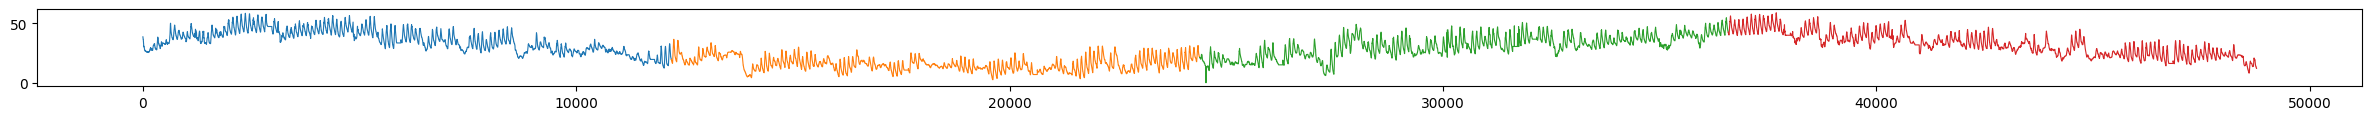

In [14]:
ETTm2 = pd.read_csv('/home/seunghan.lee/workspace/datasets/ETT-small/ETTm2.csv')
N_total = int(ETTm2.shape[0]*0.7)
N_test = int(ETTm2.shape[0]*0.1)
ETTm2_train = ETTm2.iloc[:N_total,:]
ETTm2_test = ETTm2.iloc[-N_test:,:]
N = int(N_total*0.25)

plt.figure(figsize=(30,1))
lw_ = 0.8
# cols = 'LULL'
# cols = 'LUFL'
# cols = 'MULL'
# cols = 'MUFL'
# cols = 'HULL'
# cols = 'HUFL'
cols = 'OT'
plt.plot(ETTm2_train[cols][(N*0):(N*1)],lw=lw_)
plt.plot(ETTm2_train[cols][(N*1):(N*2)],lw=lw_)
plt.plot(ETTm2_train[cols][(N*2):(N*3)],lw=lw_)
plt.plot(ETTm2_train[cols][(N*3):(N*4)],lw=lw_)

segments: 6652, per-section counts: [1461 1461 1461 1461  808]


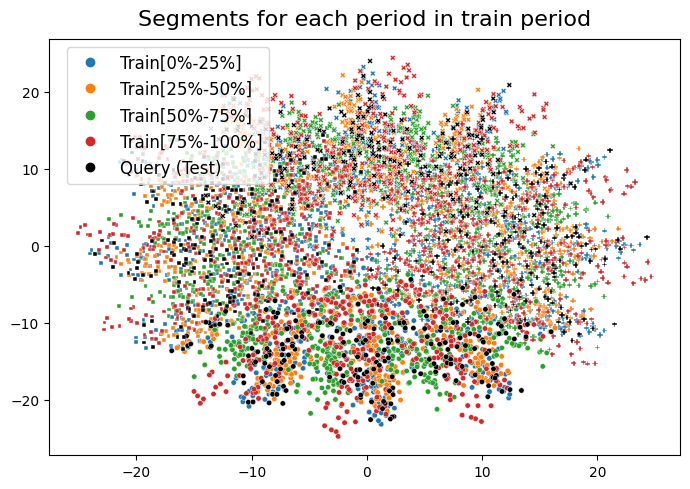

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns

# Parameters
window_size = 512
stride = 8  # increase stride if too many segments
n_clusters = 4

# Legend customization
#legend_title = "section"
section_label_map = {0: "Train[0%-25%]", 1: "Train[25%-50%]", 2: "Train[50%-75%]", 3: "Train[75%-100%]", 4: "Query (Test)"}
section_palette = {
    "Train[0%-25%]": "tab:blue",
    "Train[25%-50%]": "tab:orange",
    "Train[50%-75%]": "tab:green",
    "Train[75%-100%]": "tab:red",
    "Query (Test)": "black",
}

series_train = ETTm2_train[cols].values.astype(float)
series_test = ETTm2_test[cols].values.astype(float)
segments = []
section_ids = []  # 0-3: train quarters, 4: test

# build segments for each of the 4 train quarters
for sec in range(4):
    start = sec * N
    end = (sec + 1) * N
    for s in range(start, end - window_size + 1, stride):
        seg = series_train[s : s + window_size]
        seg = (seg-seg.min())/(seg.max()-seg.min()+1e-6)
        segments.append(seg)
        section_ids.append(sec)

# build segments from test split as section 4 (if long enough)
if len(series_test) >= window_size:
    for s in range(0, len(series_test) - window_size + 1, stride):
        seg = series_test[s : s + window_size]
        seg = (seg-seg.min())/(seg.max()-seg.min()+1e-6)        
        segments.append(seg)
        section_ids.append(4)

segments = np.stack(segments)  # (num_segments, window_size)
section_ids = np.array(section_ids)

# Normalize each segment, then cluster
scaler = StandardScaler()
segments_scaled = scaler.fit_transform(segments)

pca = PCA(n_components=2, random_state=0)
emb2d = pca.fit_transform(segments_scaled)

km = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto')
cluster_labels = km.fit_predict(segments_scaled)

counts = np.bincount(section_ids)
print(f"segments: {segments.shape[0]}, per-section counts: {counts}")

section_labels_named = np.array([section_label_map.get(int(s), f"sec-{s}") for s in section_ids])
cluster_labels_named = np.array([f"c{int(c)}" for c in cluster_labels])

hue_order = [section_label_map[k] for k in sorted(section_label_map.keys())]
palette = {k: section_palette[k] for k in hue_order}

plt.figure(figsize=(7,5))
ax = sns.scatterplot(
    x=emb2d[:,0], y=emb2d[:,1],
    hue=section_labels_named,
    style=cluster_labels_named,
    hue_order=hue_order,
    palette=palette,
    s=15, linewidth=0.3,
    legend=False,  # suppress style legend
)
#plt.title(f"PCA of segments for each period in train datasets")
plt.title(f"Segments for each period in train period",fontsize=16,pad=10)
#plt.xlabel("PC1")
#plt.ylabel("PC2")
#plt.ylim(-15,15)

# Add hue-only legend
handles = []
labels = []
for sec in hue_order:
    handles.append(plt.Line2D([], [], marker='o', color=palette[sec], linestyle='', markersize=6))
    labels.append(sec)
#ax.legend(handles, labels, title=legend_title, bbox_to_anchor=(1.05, 1), loc="upper left")
#ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=13)
ax.legend(handles, labels, bbox_to_anchor=(0.015, 1), loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()

In [37]:
# Similarity of a query segment to each section (one scalar per section)
# Uses cosine similarity on the standardized 512-length segments built above.

# choose a query: first test segment if available, else first train segment
if len(series_test) >= window_size:
    query_raw = series_test[:window_size]
else:
    query_raw = series_train[:window_size]

# scale with the same scaler, then L2-normalize
query_scaled = scaler.transform(query_raw.reshape(1, -1))
query_norm = query_scaled / (np.linalg.norm(query_scaled, axis=1, keepdims=True) + 1e-12)
segments_norm = segments_scaled / (np.linalg.norm(segments_scaled, axis=1, keepdims=True) + 1e-12)

# cosine similarities to all segments, then average per section id
sims = (segments_norm @ query_norm.T).squeeze(-1)  # (num_segments,)
uniq_sections = sorted(np.unique(section_ids))
rows = []
for sec in uniq_sections:
    mask = section_ids == sec
    rows.append({
        'section': section_label_map.get(int(sec), f'sec-{sec}'),
        'mean_cosine': sims[mask].mean().item(),
        'count': mask.sum().item(),
    })

sim_df = pd.DataFrame(rows)
display(sim_df)



,section,mean_cosine,count
0,Train[0%-25%],-0.027811,1461
1,Train[25%-50%],0.015504,1461
2,Train[50%-75%],-0.017330,1461
3,Train[75%-100%],-0.021116,1461
4,Query (Test),0.048719,808


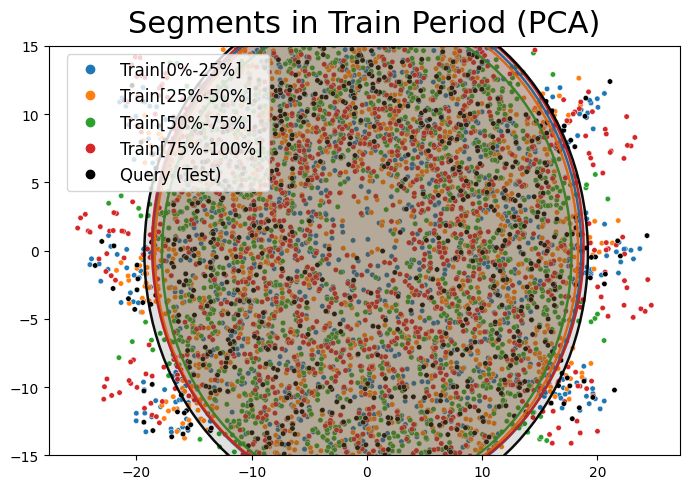

In [38]:
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors

# Scatter + translucent ellipses per section (period)
plt.figure(figsize=(7,5))
ax = sns.scatterplot(
    x=emb2d[:,0], y=emb2d[:,1],
    hue=section_labels_named,
#     style=cluster_labels_named,
    hue_order=hue_order,
    palette=palette,
    s=15, linewidth=0.3,
    legend=False,
)

# add ellipses
scale = 1.8  # std scaling for ellipse radii
for sec in hue_order:
    mask = section_labels_named == sec
    pts = emb2d[mask]
    if len(pts) < 2:
        continue
    mean = pts.mean(axis=0)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))
    width, height = 2 * scale * np.sqrt(np.maximum(eigvals, 1e-9))
    face_col = mcolors.to_rgba(palette[sec], 0.12)
    edge_col = mcolors.to_rgba(palette[sec], 0.95)
    ell = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=edge_col,
        facecolor=face_col,
        lw=1.8,
    )
    ax.add_patch(ell)

plt.title(f"Segments in Train Period (PCA)",fontsize=22,pad=10)
# plt.xlabel("PC1")
# plt.ylabel("PC2")
plt.ylim(-15,15)

# hue-only legend
handles = []
labels = []
for sec in hue_order:
    handles.append(plt.Line2D([], [], marker='o', color=palette[sec], linestyle='', markersize=6))
    labels.append(sec)
ax.legend(handles, labels, bbox_to_anchor=(0.015, 1), loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()



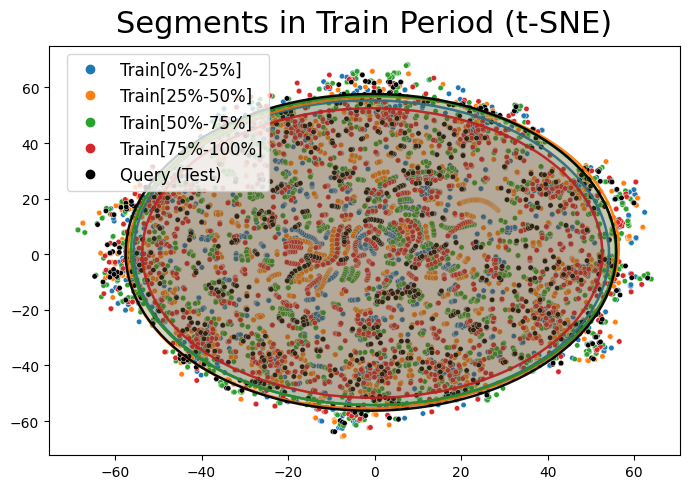

In [39]:
from sklearn.manifold import TSNE
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors

# t-SNE embedding and ellipses per section

perplexity = 30
learning_rate = 'auto'
max_iter = 1000

# t-SNE on standardized segments
emb_tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=learning_rate,
    max_iter=max_iter,
    init="pca",
    random_state=0,
).fit_transform(segments_scaled)

plt.figure(figsize=(7,5))
ax = sns.scatterplot(
    x=emb_tsne[:,0], y=emb_tsne[:,1],
    hue=section_labels_named,
#     style=cluster_labels_named,
    hue_order=hue_order,
    palette=palette,
    s=15, linewidth=0.3,
    legend=False,
)

# add ellipses
scale = 1.8
for sec in hue_order:
    mask = section_labels_named == sec
    pts = emb_tsne[mask]
    if len(pts) < 2:
        continue
    mean = pts.mean(axis=0)
    cov = np.cov(pts.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))
    width, height = 2 * scale * np.sqrt(np.maximum(eigvals, 1e-9))
    face_col = mcolors.to_rgba(palette[sec], 0.12)
    edge_col = mcolors.to_rgba(palette[sec], 0.95)
    ell = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=edge_col,
        facecolor=face_col,
        lw=1.8,
    )
    ax.add_patch(ell)

plt.title(f"Segments in Train Period (t-SNE)",fontsize=22,pad=10)
plt.ylim(None, None)

# hue-only legend
handles = []
labels = []
for sec in hue_order:
    handles.append(plt.Line2D([], [], marker='o', color=palette[sec], linestyle='', markersize=6))
    labels.append(sec)
ax.legend(handles, labels, bbox_to_anchor=(0.015, 1), loc="upper left", fontsize=12)

plt.tight_layout()
plt.show()



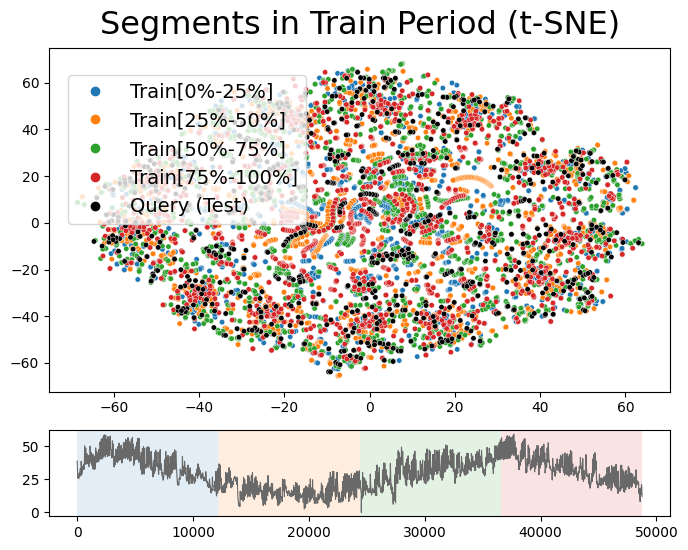

In [57]:
# Combined: t-SNE scatter with ellipses (top) + raw OT segments by quarter (bottom)
from sklearn.manifold import TSNE
from matplotlib.patches import Ellipse
import matplotlib.colors as mcolors

perplexity = 30
learning_rate = 'auto'
max_iter = 1000
scale = 1.8

# layout controls
figsize = (7, 5.6)
height_ratios = [4, 1]  # [top, bottom]; edit here


fig, axes = plt.subplots(2, 1, figsize=figsize, gridspec_kw={'height_ratios': height_ratios})
ax = axes[0]
ax = sns.scatterplot(
    x=emb_tsne[:,0], y=emb_tsne[:,1],
    hue=section_labels_named,
    hue_order=hue_order,
    palette=palette,
    s=15, linewidth=0.3,
    legend=False,
    ax=ax,
)
# ellipses
# for sec in hue_order:
#     mask = section_labels_named == sec
#     pts = emb_tsne[mask]
#     if len(pts) < 2:
#         continue
#     mean = pts.mean(axis=0)
#     cov = np.cov(pts.T)
#     eigvals, eigvecs = np.linalg.eigh(cov)
#     order = eigvals.argsort()[::-1]
#     eigvals, eigvecs = eigvals[order], eigvecs[:, order]
#     angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))
#     width, height = 2 * scale * np.sqrt(np.maximum(eigvals, 1e-9))
#     face_col = mcolors.to_rgba(palette[sec], 0.12)
#     edge_col = mcolors.to_rgba(palette[sec], 0.95)
#     ell = Ellipse(
#         xy=mean,
#         width=width,
#         height=height,
#         angle=angle,
#         edgecolor=edge_col,
#         facecolor=face_col,
#         lw=1.8,
#     )
#     ax.add_patch(ell)
ax.set_title("Segments in Train Period (t-SNE)", fontsize=23, pad=10)
ax.set_ylim(None, None)
#ax.set_xlim(-89,89)

# hue-only legend
handles = []
labels = []
for sec in hue_order:
    handles.append(plt.Line2D([], [], marker='o', color=palette[sec], linestyle='', markersize=6))
    labels.append(sec)
ax.legend(handles, labels, bbox_to_anchor=(0.015, 0.95), loc="upper left", fontsize=14)

# bottom plot: raw OT continuous line with quarter spans
ax2 = axes[1]
ax2.plot(ETTm2_train[cols].values, lw=lw_, color="dimgray")
# shade quarters
bounds = [0, N, 2*N, 3*N, 4*N]
for i in range(4):
    ax2.axvspan(bounds[i], bounds[i+1], color=palette[hue_order[i]], alpha=0.13, lw=0)
# ax2.set_title(f"OT continuous (train) with quarter spans", fontsize=14, pad=6)
# ax2.set_xlabel("time index")
# ax2.set_ylabel("OT")

plt.tight_layout()
SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures'
fn = "various_alphas.pdf"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()


In [41]:
# print(ettm2_base)
# print(ettm2_ours)
ettm2_base = np.array(ettm2_base)
ettm2_ours = np.array(ettm2_ours)

In [42]:
print(ettm2_base[[3,4,5]]) # 1470
print(ettm2_ours[[3,4,5]]) # 1435

[0.1489 0.1486 0.1485]
[0.1467 0.1458 0.1463]


In [249]:
ettm2_ours

array([0.1467, 0.1463, 0.1469, 0.1467, 0.1458, 0.1463])

In [ ]:
# ours_alpha5 = [x for x in settings_ours if 'alpha5.' in x]
# ours_alpha10 = [x for x in settings_ours if 'alpha10.' in x]
# ours_alpha20 = [x for x in settings_ours if 'alpha20.' in x]
# ours_alpha25 = [x for x in settings_ours if 'alpha25.' in x]
# ours_alpha50 = [x for x in settings_ours if 'alpha50.' in x]
# ours_alpha75 = [x for x in settings_ours if 'alpha75.' in x]

In [ ]:
c|cccc
Train period & \multicolumn{4}{c}{Construction of Retrieval Knowledge} \\
\midrule
0-25 & & & & \cmark \\
25-50  & & &\cmark & \cmark \\
50-75 & &\cmark &\cmark & \cmark \\
75-100 &\cmark &\cmark & \cmark& \cmark \\
\midrule
TS-RAG (NeurIPS 2025) & 0.1489 & 0.1486 & 0.1485 & 0.1470 \\
Cross-RAG (Ours)& 0.1467 & 0.1458 & 0.1463 & 0.1435 \\
\bottomrule
